# Pairs trading on minute bars — I. The minute lake and the microstructure of the spread

## `pairs_trading_15_minute_data.ipynb`

The Yahoo daily notebooks (`pairs_trading_01`–`05`) screen, hedge and trade on daily closes. This series moves
the same pipeline to **minute aggregates** from a local Polygon-derived parquet lake:

| notebook | question |
|---|---|
| **09 (this one)** | What is in the lake, how do minute bars become a clean trading-session grid, which names are liquid enough, which pairs are candidates, and what does a cointegrated spread look like *within the day*? |
| 10 | Which intraday design works on the training span: sampling frequency, session rules, hedge cadence, thresholds — chosen on pooled out-of-fold Sharpe |
| 11 | Does it survive a hold-out touched once, realistic latency and costs, capacity, and does it beat trading the same pairs on daily bars? |

Everything runs on the package API. Two additions were made for minute data:
`pairs.market_data.minute_bars` (the lake loader and session grid) and `pairs.stats.microstructure`
(Roll spread, signature plot, Epps effect, bounce autocorrelation).

**Data span.** Sessions from 2022-01-03 to 2025-08-13 (the last day in the lake). The **training span**
is 2022-01-03 → 2024-12-31; 2025 is reserved as the hold-out for notebook 17. The cointegration screen
below, and every design choice in notebook 16, use the training span only. One caveat worth stating: the
liquidity universe is built from session statistics over the *whole* span, and requires full coverage of
it, so hold-out information does reach ticker **eligibility** — though not pair selection.

**Caching.** The universe pass and the screen are cached under `notebooks/cache/` (gitignored). A cold run
takes about 3 minutes on 16 cores; a warm run about 20 seconds. The lake is read-only; set the environment
variable `MINUTE_LAKE` if it lives somewhere other than `~/local/parquet_lake/minute_adj`.

## 0. Setup

In [1]:
from pathlib import Path
import os, sys, time, warnings

repo_root = Path.cwd().parent           # notebooks/ → repo root
sys.path.insert(0, str(repo_root))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq

import pairs
from pairs import (load_universe, load_minute_bars, detect_lake_layout, nyse_early_closes, summarize_sessions,
                   find_cointegrated_pairs_dualgate, roll_spread, realized_variance_signature,
                   epps_correlation, autocorr_by_interval, estimate_halflife)
from pairs.market_data.minute_bars import _read_market_day

LAKE        = Path(os.environ.get("MINUTE_LAKE", Path.home() / "local/parquet_lake/minute_adj"))
TICKER_ROOT = LAKE / "spx_ndx_combined_adjusted"     # one file per ticker-day  (used throughout)
MARKET_ROOT = LAKE / "all_adjusted"                  # one file per day, all tickers + sidecar (shown in §1)
CACHE = Path("cache"); CACHE.mkdir(exist_ok=True)

START, TRAIN_END, END = "2022-01-03", "2024-12-31", "2025-08-13"
UNIVERSE = "spx_ndx_combined"
N_CANDIDATES = 24                                     # pairs carried into notebooks 16 and 13

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 100})
LAKE_LABEL = f"~/{LAKE.relative_to(Path.home())}" if LAKE.is_relative_to(Path.home()) else str(LAKE)
print("pairs", pairs.__version__, "| lake:", LAKE_LABEL, "| layouts:",
      detect_lake_layout(TICKER_ROOT), "/", detect_lake_layout(MARKET_ROOT) if MARKET_ROOT.exists() else "n/a")

pairs 0.1.0 | lake: ~/local/parquet_lake/minute_adj | layouts: ticker / market


## 1. The minute lake

The lake holds one-minute aggregates (2003 → 2025-08-13) in two layouts:

| layout | path | when |
|---|---|---|
| **ticker** | `spx_ndx_combined_adjusted/<TICKER>/<YYYY>/<MM>/<DD>.parquet` | one file per ticker-day; ~2.4 M files for 517 names |
| **market** | `all_adjusted/<YYYY>/<MM>/<DD>.parquet` + `<DD>.idx.parquet` | one file per day for *every* listed symbol (~1.5 M rows, sorted ticker-major in 128k-row row groups); the sidecar records each ticker's `row_start`/`row_end` so one symbol is read from its row groups only |

The full market (33k symbols × 5.5k days) cannot use the ticker layout — that would be over 100 million tiny
files — hence the market layout. For a 500-name universe the ticker layout is convenient and fast, and it
is what the rest of the series uses.

Every row carries the raw close, split-adjusted (`close_split`) and split-and-dividend-adjusted
(`close_tr`, total return) prices with their factors, split-adjusted and total-return variants of
open/high/low (there is no raw open/high/low), raw and
split-adjusted volume, and a Bloomberg FIGI. Timestamps are **UTC without a timezone marker** and label the
**start** of the minute. The bars run 04:00–20:00 Eastern, so pre- and post-market prints are included.

In [2]:
sample = TICKER_ROOT / "NVDA" / "2024" / "06" / "10.parquet"
pf = pq.ParquetFile(sample)
print(f"{sample.relative_to(LAKE)}: {pf.metadata.num_rows} rows, {pf.metadata.num_row_groups} row group(s)")
print(pf.schema_arrow.to_string(show_schema_metadata=False))

spx_ndx_combined_adjusted/NVDA/2024/06/10.parquet: 960 rows, 1 row group(s)
datetime: timestamp[ns]
ticker: large_string
id: large_string
close: double
volume: int64
close_split: double
volume_split: double
close_tr: double
split_price_factor: double
tr_price_factor: double
open_split: double
high_split: double
low_split: double
open_tr: double
high_tr: double
low_tr: double


NVDA split 10-for-1 on 2024-06-10. The raw close drops tenfold, `close_split` is continuous, and `close_tr`
additionally scales by the (tiny, for NVDA) dividend factor. Pairs work needs a series that is continuous
across corporate actions, so the loader uses `close_tr` by default.

In [3]:
rows = []
for d in ("2024/06/07", "2024/06/10"):
    df = pq.read_table(TICKER_ROOT / "NVDA" / f"{d}.parquet").to_pandas()
    last = df.loc[df["datetime"].idxmax()]
    rows.append({"day": d, "last bar (UTC)": last["datetime"], "close": last["close"], "close_split": last["close_split"],
                 "close_tr": last["close_tr"], "split_price_factor": last["split_price_factor"],
                 "tr_price_factor": last["tr_price_factor"], "volume": last["volume"], "volume_split": last["volume_split"]})
pd.DataFrame(rows).set_index("day").T

day,2024/06/07,2024/06/10
last bar (UTC),2024-06-07 23:59:00,2024-06-10 23:59:00
close,1207.75,121.6005
close_split,120.775,121.6005
close_tr,120.726933,121.552105
split_price_factor,0.1,1.0
tr_price_factor,0.999602,0.999602
volume,7526,23165
volume_split,75260.0,23165.0


### 1.1 The market layout and its sidecar

Reading one symbol from a day file means: look up its row range in the sidecar, map the range onto the
file's row-group offsets, read only those groups. `load_minute_bars` does this automatically when it
detects the market layout; here it is done by hand to show what happens.

In [4]:
if MARKET_ROOT.exists():
    day, sidecar = MARKET_ROOT / "2024/06/10.parquet", MARKET_ROOT / "2024/06/10.idx.parquet"
    pf_day = pq.ParquetFile(day)
    idx = pq.read_table(sidecar).to_pandas()
    sizes = [pf_day.metadata.row_group(i).num_rows for i in range(pf_day.metadata.num_row_groups)]
    print(f"{day.name}: {pf_day.metadata.num_rows:,} rows, {len(idx):,} tickers, row groups {sizes[:3]}… ({len(sizes)} groups)")
    print(idx[idx["ticker"].isin(["A", "AAPL", "NVDA", "ZTS"])].to_string(index=False))

    cols = ["datetime", "ticker", "close_tr", "volume"]
    t0 = time.perf_counter(); via_sidecar = _read_market_day(day, ["NVDA"], cols); t_side = time.perf_counter() - t0
    t0 = time.perf_counter(); via_ticker = pq.read_table(TICKER_ROOT / "NVDA/2024/06/10.parquet", columns=cols).to_pandas(); t_tick = time.perf_counter() - t0
    same = (len(via_sidecar) == len(via_ticker)
            and np.allclose(via_sidecar["close_tr"].to_numpy(), via_ticker["close_tr"].to_numpy())
            and (via_sidecar["datetime"].to_numpy() == via_ticker["datetime"].to_numpy()).all())
    print(f"\nNVDA 2024-06-10: {len(via_sidecar)} rows via sidecar in {t_side*1e3:.1f} ms, "
          f"{len(via_ticker)} rows from the ticker file in {t_tick*1e3:.1f} ms; identical: {same}")
else:
    print("market layout not available at", MARKET_ROOT)

10.parquet: 1,443,600 rows, 10,188 tickers, row groups [131072, 131072, 131072]… (12 groups)
ticker  first_close  last_close  n_rows  row_start  row_end
     A       132.87    133.1000     374          0      373
  AAPL       197.46    192.3300     873       3510     4382
  NVDA       120.20    121.6005     960     904793   905752
   ZTS       176.69    178.8300     387    1441402  1441788

NVDA 2024-06-10: 960 rows via sidecar in 6.4 ms, 960 rows from the ticker file in 0.9 ms; identical: True


### 1.2 Do the two builds agree?

Both layouts were built from the same raw aggregates but adjusted separately, so it is worth checking that
they carry the same prices. Comparing every universe ticker on one day: the raw closes and volumes are
identical; the *adjusted* prices differ for a handful of names whose dividend factor (`tr_price_factor`)
or split factor differs between the two builds. Mixing layouts would therefore silently mix adjustment
histories — this series reads the ticker layout only.

In [5]:
if MARKET_ROOT.exists():
    universe = load_universe(UNIVERSE)
    cols = ["datetime", "ticker", "close", "close_split", "close_tr", "split_price_factor", "tr_price_factor", "volume"]
    day = "2024/06/10"
    mkt = _read_market_day(MARKET_ROOT / f"{day}.parquet", list(universe), cols).set_index(["ticker", "datetime"]).sort_index()
    tick = pd.concat([pq.read_table(TICKER_ROOT / t / f"{day}.parquet", columns=cols).to_pandas()
                      for t in universe if (TICKER_ROOT / t / f"{day}.parquet").exists()]).set_index(["ticker", "datetime"]).sort_index()
    common = mkt.index.intersection(tick.index)
    a, b = mkt.loc[common], tick.loc[common]
    print(f"{day}: {len(common):,} common rows; rows only in one layout: {len(mkt.index.symmetric_difference(tick.index))}")
    report = {}
    for c in ("close", "volume", "close_split", "close_tr", "split_price_factor", "tr_price_factor"):
        bad = ~np.isclose(a[c].astype(float), b[c].astype(float), rtol=1e-9, equal_nan=True)
        report[c] = sorted(set(common[bad].get_level_values("ticker")))
    for c, names in report.items():
        print(f"  {c:20s} differs for {len(names):2d} ticker(s) {names}")
    diff_names = report["close_tr"]
    if diff_names:
        show = pd.DataFrame({t: {"market tr_price_factor": a.loc[t, "tr_price_factor"].iloc[0], "ticker tr_price_factor": b.loc[t, "tr_price_factor"].iloc[0],
                                 "market split_factor": a.loc[t, "split_price_factor"].iloc[0], "ticker split_factor": b.loc[t, "split_price_factor"].iloc[0],
                                 "close_tr ratio (market/ticker)": a.loc[t, "close_tr"].iloc[0] / b.loc[t, "close_tr"].iloc[0]} for t in diff_names}).T
        display(show.round(5))

2024/06/10: 189,285 common rows; rows only in one layout: 0
  close                differs for  0 ticker(s) []
  volume               differs for  0 ticker(s) []
  close_split          differs for  1 ticker(s) ['PARA']
  close_tr             differs for  3 ticker(s) ['ACGL', 'BK', 'PARA']
  split_price_factor   differs for  1 ticker(s) ['PARA']
  tr_price_factor      differs for  2 ticker(s) ['ACGL', 'BK']


,market tr_price_factor,ticker tr_price_factor,market split_factor,ticker split_factor,close_tr ratio (market/ticker)
ACGL,0.92058,0.95094,1.0,1.0,0.96807
BK,0.96123,0.96984,1.0,1.0,0.99112
PARA,0.97765,0.97765,500.0,1.0,500.00000


## 2. Sessions and the regular grid

`load_minute_bars(tickers, start, end, root, freq=...)` turns raw lake rows into bars on a **regular
trading-session grid**:

* UTC timestamps → Eastern (DST handled), then only regular hours 09:30–16:00 are kept — 09:30–13:00 on
  the NYSE early-close days (day after Thanksgiving; July 3 and December 24 when they fall Monday–Thursday).
  The lake keeps printing after an early close because the after-hours session starts at 13:00, so the
  calendar rule is needed; bar counts alone would not identify those days.
* every minute of every session is present. A minute without a trade carries the last traded price forward
  **within the session** (a session never inherits the previous close), with `volume` 0 and `n_traded` 0.
  Minutes before a session's first trade are NaN.
* `freq="5min"` (any whole number of minutes) aggregates the grid per session — bars labelled by their
  start, close = last, volume = sum, `n_traded` = traded minutes in the bar; `freq="session"` gives one row
  per session with open/close/volume/dollar volume, traded minutes, grid length and a Roll spread estimate.
* bars are labelled by their **start** minute (the lake's convention): the close of the bar labelled 09:30
  is the last trade before 09:31. Signal timing in notebook 16 is built on this.

In [6]:
print("early closes in the span:", [d.date().isoformat() for d in nyse_early_closes(START, END)])
demo = load_minute_bars(["AAPL", "CCL"], "2024-11-25", "2024-12-03", TICKER_ROOT)          # 1-minute grid
a = demo.loc["AAPL"]
per_session = a.groupby(a.index.normalize()).agg(bars=("close", "size"), first_bar=("close", lambda s: s.index[0].time()),
                                                 last_bar=("close", lambda s: s.index[-1].time()),
                                                 untraded_minutes=("n_traded", lambda s: int((s == 0).sum())))
display(per_session)
demo5 = load_minute_bars(["AAPL", "CCL"], "2024-11-25", "2024-12-03", TICKER_ROOT, freq="5min")
demo_s = load_minute_bars(["AAPL", "CCL"], "2024-11-25", "2024-12-03", TICKER_ROOT, freq="session")
print("5-minute bars per session (CCL):", demo5.loc["CCL"].groupby(demo5.loc["CCL"].index.normalize()).size().to_dict())
display(demo_s.loc["CCL"].round(3))

early closes in the span: ['2022-11-25', '2023-07-03', '2023-11-24', '2024-07-03', '2024-11-29', '2024-12-24', '2025-07-03']


,bars,first_bar,last_bar,untraded_minutes
datetime,,,,
2024-11-25,390,09:30:00,15:59:00,0
2024-11-26,390,09:30:00,15:59:00,0
2024-11-27,390,09:30:00,15:59:00,0
2024-11-29,210,09:30:00,12:59:00,0
2024-12-02,390,09:30:00,15:59:00,0
2024-12-03,390,09:30:00,15:59:00,0


5-minute bars per session (CCL): {Timestamp('2024-11-25 00:00:00'): 78, Timestamp('2024-11-26 00:00:00'): 78, Timestamp('2024-11-27 00:00:00'): 78, Timestamp('2024-11-29 00:00:00'): 42, Timestamp('2024-12-02 00:00:00'): 78, Timestamp('2024-12-03 00:00:00'): 78}


,open,close,volume,dollar_volume,n_traded,n_bars,roll_spread_bps
datetime,,,,,,,
2024-11-25,25.345,25.195,18561179.0,4.684830e+08,390,390,NaN
2024-11-26,25.205,25.340,18627267.0,4.752336e+08,390,390,4.158
2024-11-27,25.440,25.150,7846205.0,1.984873e+08,390,390,2.211
2024-11-29,25.270,25.440,6510787.0,1.654850e+08,210,210,7.994
2024-12-02,25.710,25.995,17966054.0,4.700772e+08,390,390,NaN
2024-12-03,26.210,26.115,16930152.0,4.438627e+08,390,390,3.047


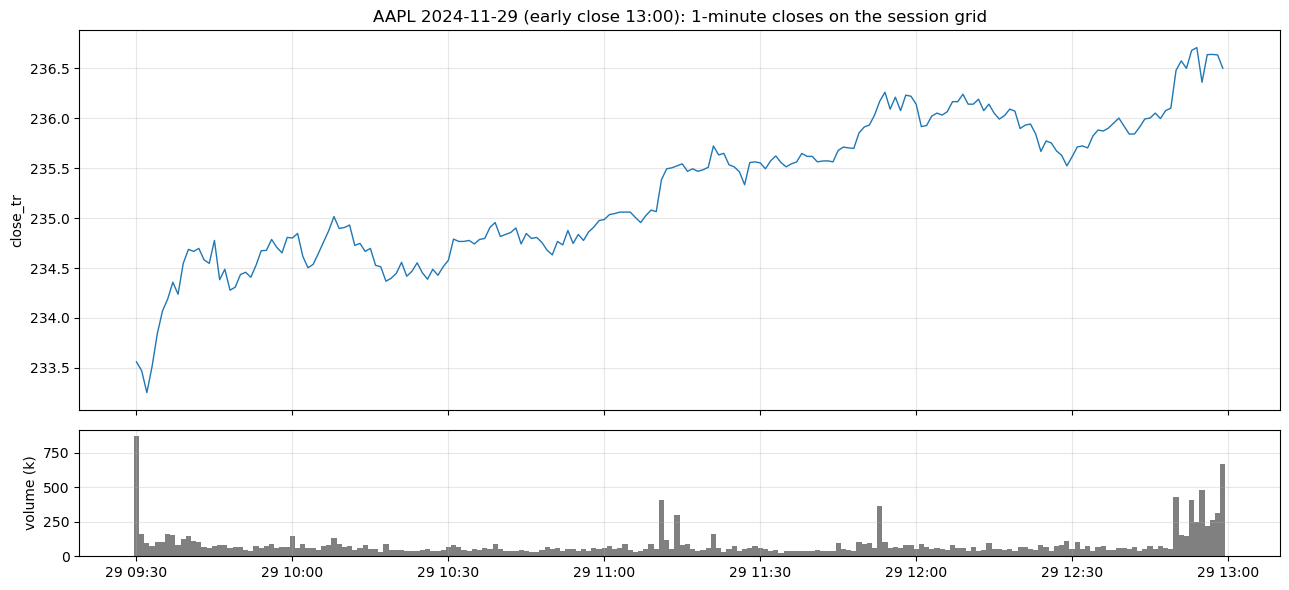

In [7]:
fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True, height_ratios=[3, 1])
s = a.loc["2024-11-29"]
ax[0].plot(s.index, s["close"], lw=1); ax[0].set_title("AAPL 2024-11-29 (early close 13:00): 1-minute closes on the session grid"); ax[0].set_ylabel("close_tr")
ax[1].bar(s.index, s["volume"] / 1e3, width=1 / 1440, color="0.5"); ax[1].set_ylabel("volume (k)")
plt.tight_layout(); plt.show()

## 3. Universe pass: session closes and liquidity

One pass over the lake for the whole universe at `freq="session"`: each worker reads a ticker's files,
builds its minute grid and reduces it to one row per session, so the universe never has to sit in memory
at minute resolution. The result (≈ 460k ticker-sessions) is cached.

As in the daily notebooks, only tickers with **full coverage** of the span are kept: the cointegration
tests need every series over the same sample.

In [8]:
f_sessions = CACHE / "min_sessions.parquet"
universe = load_universe(UNIVERSE)
if f_sessions.exists():
    sessions = pd.read_parquet(f_sessions)
else:
    t0 = time.time()
    sessions = load_minute_bars(universe, START, END, TICKER_ROOT, freq="session", show_progress=False)
    sessions.to_parquet(f_sessions)
    print(f"universe pass: {time.time() - t0:.0f}s")
summary = summarize_sessions(sessions)
n_sessions = sessions.index.get_level_values("datetime").nunique()
full = summary[summary["n_sessions"] == n_sessions]
print(f"{len(sessions):,} ticker-sessions | {n_sessions} sessions {sessions.index.get_level_values('datetime').min().date()} → "
      f"{sessions.index.get_level_values('datetime').max().date()} | {len(summary)} tickers with data, {len(full)} with full coverage")
print("dropped (incomplete coverage):", sorted(set(universe) - set(full.index)))

460,097 ticker-sessions | 906 sessions 2022-01-03 → 2025-08-13 | 517 tickers with data, 491 with full coverage
dropped (incomplete coverage): ['ARM', 'BALL', 'BIIB', 'CEG', 'COR', 'CPAY', 'DAY', 'DOC', 'EG', 'ELV', 'EXE', 'FI', 'GEHC', 'GEN', 'GEV', 'KVUE', 'META', 'PARA', 'RVTY', 'SOLV', 'SW', 'TKO', 'VLTO', 'WBD', 'WTW', 'XYZ']


### 3.1 Liquidity screen

Three per-ticker statistics from the session frame, each a median over sessions:

* **traded share** — fraction of regular-session minutes with at least one trade. Below ~0.95 the minute
  series is mostly forward-filled stale prices, and a "spread" against such a name moves whenever the
  *other* leg trades.
* **dollar volume per session** — sets how much can be traded without moving the price.
* **Roll spread** — the effective bid-ask spread implied by the negative serial covariance of minute price
  changes (Roll 1984), in basis points. This is the cost of crossing the spread, which is what an
  intraday round trip pays twice per leg.

The rule used for the rest of the series: traded share ≥ 0.95 and median dollar volume ≥ $20M per session.
It is strict on purpose — it removes a third of the universe, mostly high-priced names that trade in a few
large prints per minute (AZO, NVR, TPL, FICO, …) and are perfectly liquid on a daily grid but stale on a
minute grid.

340 liquid tickers; 151 excluded:


ticker,TPL,ERIE,MTD,AZO,FICO,NVR,TDY,TYL,NDSN,TDG,...,STZ,SYK,WSM,SPGI,DRI,TT,TRV,NSC,XYL,WRB
traded_share,0.097,0.213,0.272,0.287,0.367,0.417,0.428,0.433,0.456,0.465,...,0.938,0.938,0.941,0.941,0.944,0.944,0.944,0.946,0.949,0.949
median $M / session,9.700,14.400,96.400,224.600,108.100,80.200,66.900,67.900,31.900,146.400,...,203.000,277.800,83.600,385.100,136.000,206.900,166.700,209.100,96.900,43.400
median_roll_bps,26.062,15.458,14.746,11.906,12.104,13.159,8.675,9.672,7.529,8.844,...,3.865,4.267,6.702,3.710,3.960,4.647,3.542,4.522,3.855,3.571


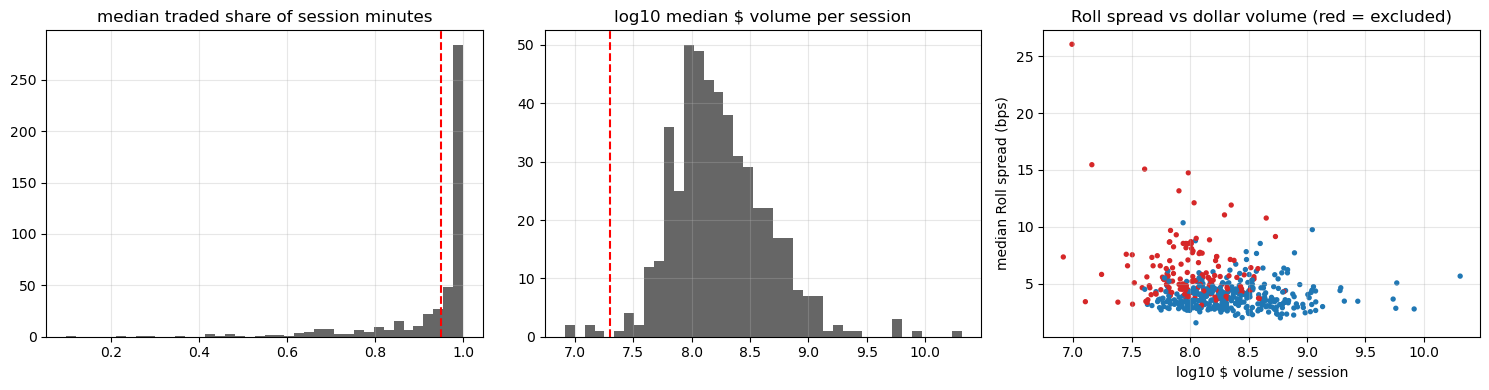

Roll spread (bps) among liquid names — quantiles: {0.1: 2.74, 0.25: 3.06, 0.5: 3.58, 0.75: 4.38, 0.9: 5.17}


In [9]:
TRADED_SHARE_MIN, DOLLAR_VOLUME_MIN = 0.95, 20e6
liquid = full[(full["traded_share"] >= TRADED_SHARE_MIN) & (full["median_dollar_volume"] >= DOLLAR_VOLUME_MIN)]
excluded = full.drop(liquid.index)
print(f"{len(liquid)} liquid tickers; {len(excluded)} excluded:")
display(excluded.sort_values("traded_share")[["traded_share", "median_dollar_volume", "median_roll_bps"]]
        .assign(median_dollar_volume=lambda d: (d["median_dollar_volume"] / 1e6).round(1)).rename(columns={"median_dollar_volume": "median $M / session"}).round(3).T)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(full["traded_share"], bins=40, color="0.4"); ax[0].axvline(TRADED_SHARE_MIN, color="r", ls="--"); ax[0].set_title("median traded share of session minutes")
ax[1].hist(np.log10(full["median_dollar_volume"]), bins=40, color="0.4"); ax[1].axvline(np.log10(DOLLAR_VOLUME_MIN), color="r", ls="--"); ax[1].set_title("log10 median $ volume per session")
ax[2].scatter(np.log10(full["median_dollar_volume"]), full["median_roll_bps"], s=8, c=np.where(full.index.isin(liquid.index), "tab:blue", "tab:red"))
ax[2].set_xlabel("log10 $ volume / session"); ax[2].set_ylabel("median Roll spread (bps)"); ax[2].set_title("Roll spread vs dollar volume (red = excluded)")
plt.tight_layout(); plt.show()
print("Roll spread (bps) among liquid names — quantiles:", liquid["median_roll_bps"].quantile([.1, .25, .5, .75, .9]).round(2).to_dict())

## 4. Candidate pairs: the dual-gate screen on session closes

The cointegration screen runs on **session closes over the training span** with the same tool and settings
as the daily notebooks (`find_cointegrated_pairs_dualgate`: Engle–Granger with Benjamini–Hochberg FDR *and*
Johansen). Two reasons not to screen on minute bars directly:

1. cointegration is a statement about the *long-run* relation; the roughly 290,000 minute observations
   over the same three years carry the same low-frequency information as 750 daily closes, plus a great
   deal of microstructure noise (§6);
2. the cost — the ADF regressions inside Engle–Granger scale with the sample, and the 58k pairs this
   screen actually tests, at 290k observations each, is not a screen, it is a weekend.

The candidates handed to notebooks 16 and 13 are the passing pairs with the smallest BH-corrected
Engle–Granger p-value, at most `N_CANDIDATES`. The 2025 hold-out is not part of the screen.

Under Benjamini–Hochberg at 5% on ~58k tests only a handful of pairs pass — far fewer than the daily
notebooks found on 2020–2025 (six years and a wider universe). Neither cut helps, in side runs not shown
here: screening on 2021–2024 session closes instead passes *nothing* (the relations that hold over
2022–2024 do not extend back through 2021), and loosening the liquidity rule to a traded share of 0.90
adds tests faster than discoveries (9 passes on 387 tickers). The candidate set is small and concentrated
on a few hubs, and the later notebooks treat it as such. The lever that would actually add candidates is
the universe: the ticker layout holds only the S&P 500 and Nasdaq-100 names, while the market layout
holds every listed symbol, and `load_minute_bars` already reads it through the sidecar — a wider screen
is a change of `TICKER_ROOT` and a ticker list, at the cost of a longer universe pass and a stricter BH
threshold.

In [10]:
f_screen = CACHE / "min_screen.parquet"
if f_screen.exists():
    screen = pd.read_parquet(f_screen)
else:
    closes = sessions.loc[pd.IndexSlice[liquid.index, :], ["close"]]
    closes = closes[closes.index.get_level_values("datetime") <= pd.Timestamp(TRAIN_END)]
    t0 = time.time()
    screen = find_cointegrated_pairs_dualgate(closes, alpha_eg=0.05, alpha_joh=0.05, fdr_method="bh", show_progress=False)
    screen.to_parquet(f_screen)
    print(f"screen: {len(screen):,} pairs in {time.time() - t0:.0f}s")
passed = screen[screen["verdict"] == "pass"].sort_values("eg_p_fdr")
print(f"{len(screen):,} pairs tested on {liquid.shape[0]} tickers: EG(BH) pass {int(screen['eg_pass'].sum())}, "
      f"Johansen pass {int(screen['joh_pass'].sum())}, both {len(passed)}")
degree = pd.Series([t for p in passed.index for t in p]).value_counts()
print("most connected tickers among passing pairs:", degree.head(8).to_dict())
candidates = passed.head(N_CANDIDATES).copy()
candidates.to_parquet(CACHE / "min_candidates.parquet")
display(candidates[["eg_t", "eg_p", "eg_p_fdr", "joh_stat"]].round(4))

57,630 pairs tested on 340 tickers: EG(BH) pass 10, Johansen pass 14254, both 10
most connected tickers among passing pairs: {'TROW': 4, 'PYPL': 3, 'WFC': 2, 'TSN': 1, 'GM': 1, 'TFC': 1, 'APTV': 1, 'WM': 1}


eg_t  eg_p  eg_p_fdr  joh_stat
ticker1 ticker2                                  
PYPL    TSN     -7.4105   0.0    0.0001   41.5169
GM      WFC     -6.3516   0.0    0.0079   41.4426
PYPL    TFC     -6.1010   0.0    0.0188   42.3262
APTV    WM      -5.9527   0.0    0.0241   36.3704
TROW    USB     -5.9487   0.0    0.0241   41.1922
        VZ      -5.8871   0.0    0.0266   40.1678
        WFC     -5.8603   0.0    0.0266   35.0331
JPM     NFLX    -5.7774   0.0    0.0309   32.3640
TROW    VTR     -5.7976   0.0    0.0309   35.4487
PYPL    XEL     -5.6854   0.0    0.0432   41.7032

## 5. Minute bars for the candidate tickers

The full minute grid is loaded only for the tickers in the candidate pairs (both spans, since notebook 17
needs 2025) and cached. Wide frames — one column per ticker — are the working format for the rest of the
notebook.

In [11]:
cand_tickers = sorted({t for p in candidates.index for t in p})
f_1m = CACHE / "min_candidates_1m.parquet"
if f_1m.exists():
    bars_1m = pd.read_parquet(f_1m)
else:
    t0 = time.time()
    bars_1m = load_minute_bars(cand_tickers, START, END, TICKER_ROOT, freq="1min")
    bars_1m.to_parquet(f_1m)
    print(f"1-minute bars for {len(cand_tickers)} tickers: {time.time() - t0:.0f}s")
close_1m  = bars_1m["close"].unstack("ticker")
traded_1m = bars_1m["n_traded"].unstack("ticker")
vol_1m    = bars_1m["volume"].unstack("ticker")
session_of = close_1m.index.normalize()
print(f"{close_1m.shape[0]:,} minutes × {close_1m.shape[1]} tickers, {session_of.nunique()} sessions; "
      f"NaN share {close_1m.isna().mean().mean():.2%}, untraded-minute share {(traded_1m == 0).mean().mean():.2%}")

352,080 minutes × 14 tickers, 906 sessions; NaN share 0.00%, untraded-minute share 0.90%


## 6. The intraday microstructure of the spread

For these diagnostics the spread of each candidate is the **static** Engle–Granger residual,
$s_t = P_{1,t} - \hat\beta P_{2,t} - \hat\alpha$ with $\hat\alpha, \hat\beta$ from OLS on the training-span
session closes — the same hedge the screen implicitly tested. It is deliberately not the Kalman hedge:
a filter that re-estimates the hedge every minute would absorb part of what we want to measure (notebook 16
compares Kalman hedges against this static one at five-minute bars, then sweeps frequency with the
static hedge).

Four questions, each answered by sampling the same minute series every $k$ minutes:

1. **Signature plot** — realized variance per minute of the spread as a function of the sampling interval.
   A random walk gives a flat line; bid-ask bounce and stale prices inflate it at fine sampling.
2. **Epps effect** — correlation of the two legs' returns by interval. If it is still rising at 5 minutes,
   a 1-minute hedge ratio is estimated on a relation the data do not yet show.
3. **Bounce** — first-order autocorrelation of spread changes by interval. Negative at 1 minute means
   "mean reversion" that is the spread bouncing between bid and ask, which cannot be captured net of the
   spread it *is*.
4. **Half-life** of the spread by interval, and on session closes, in minutes.

In [12]:
sess_close = sessions["close"].unstack("ticker")[cand_tickers]
train_close = sess_close[sess_close.index <= pd.Timestamp(TRAIN_END)]

def static_hedge(t1, t2):
    y, x = train_close[t1], train_close[t2]
    X = np.column_stack([np.ones(len(x)), x.to_numpy()])
    (alpha, beta), *_ = np.linalg.lstsq(X, y.to_numpy(), rcond=None)
    return float(alpha), float(beta)

hedges = {p: static_hedge(*p) for p in candidates.index}
spreads_1m = pd.DataFrame({p: close_1m[p[0]] - hedges[p][1] * close_1m[p[1]] - hedges[p][0] for p in candidates.index})
spreads_1m.columns = [f"{a}/{b}" for a, b in spreads_1m.columns]
INTERVALS = (1, 2, 5, 10, 15, 30, 60)
pair_labels = list(spreads_1m.columns)
print("static hedges (alpha, beta) on training session closes:")
display(pd.DataFrame(hedges, index=["alpha", "beta"]).T.round(3).head(8))

static hedges (alpha, beta) on training session closes:


alpha   beta
PYPL TSN    -6.466  1.396
GM   WFC     9.567  0.641
PYPL TFC    -9.245  2.350
APTV WM    201.431 -0.637
TROW USB    52.092  1.367
     VZ     46.373  1.662
     WFC    82.415  0.502
JPM  NFLX   61.301  0.202

### 6.1 Signature plot and Epps effect

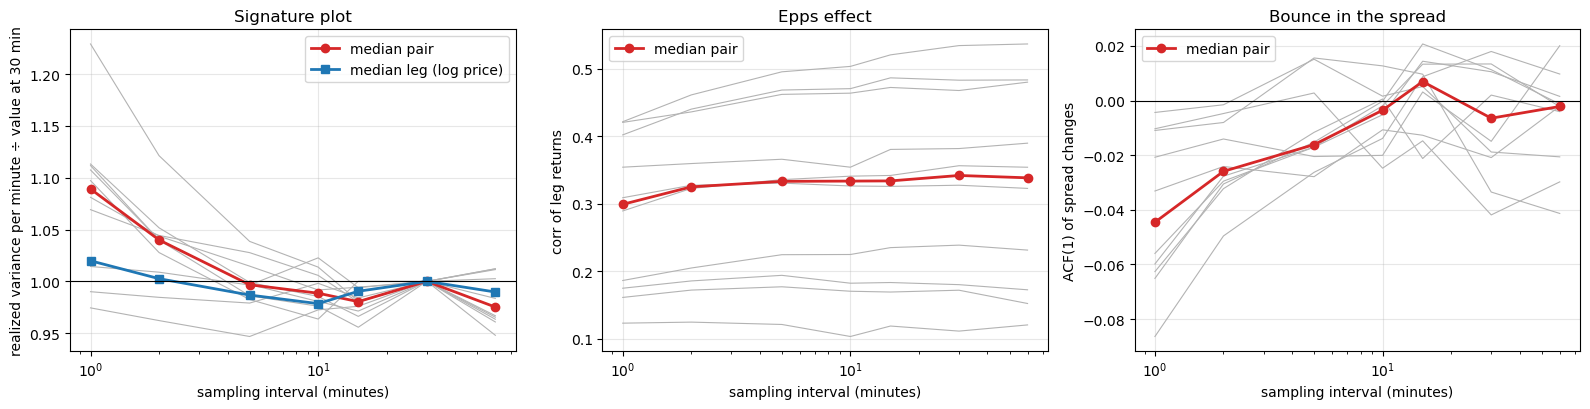

,spread RV/min ÷ 30-min (median),leg RV/min ÷ 30-min (median),Epps corr (median),spread ACF(1) (median)
interval,,,,
1,1.089,1.020,0.299,-0.045
2,1.040,1.003,0.325,-0.026
5,0.997,0.987,0.333,-0.016
10,0.989,0.978,0.333,-0.004
15,0.980,0.990,0.334,0.007
30,1.000,1.000,0.342,-0.006
60,0.975,0.990,0.338,-0.002


In [13]:
sig_spread = pd.DataFrame({lbl: realized_variance_signature(spreads_1m[lbl], INTERVALS, session=lambda i: i.normalize(), log=False) for lbl in pair_labels})
sig_legs   = pd.DataFrame({t: realized_variance_signature(close_1m[t], INTERVALS, session=lambda i: i.normalize(), log=True) for t in cand_tickers})
epps       = pd.DataFrame({f"{a}/{b}": epps_correlation(close_1m[a], close_1m[b], INTERVALS, session=lambda i: i.normalize()) for a, b in candidates.index})

def rel(df):  # normalise each column by its 30-minute value
    return df.div(df.loc[30], axis=1)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
for lbl in pair_labels: ax[0].plot(INTERVALS, rel(sig_spread)[lbl], color="0.7", lw=0.8)
ax[0].plot(INTERVALS, rel(sig_spread).median(axis=1), color="tab:red", lw=2, marker="o", label="median pair")
ax[0].plot(INTERVALS, rel(sig_legs).median(axis=1), color="tab:blue", lw=2, marker="s", label="median leg (log price)")
ax[0].axhline(1, color="k", lw=0.8); ax[0].set_xscale("log"); ax[0].set_xlabel("sampling interval (minutes)")
ax[0].set_ylabel("realized variance per minute ÷ value at 30 min"); ax[0].set_title("Signature plot"); ax[0].legend()
for lbl in epps.columns: ax[1].plot(INTERVALS, epps[lbl], color="0.7", lw=0.8)
ax[1].plot(INTERVALS, epps.median(axis=1), color="tab:red", lw=2, marker="o", label="median pair")
ax[1].set_xscale("log"); ax[1].set_xlabel("sampling interval (minutes)"); ax[1].set_ylabel("corr of leg returns"); ax[1].set_title("Epps effect"); ax[1].legend()
acf = pd.DataFrame({lbl: autocorr_by_interval(spreads_1m[lbl], INTERVALS, session=lambda i: i.normalize()) for lbl in pair_labels})
for lbl in pair_labels: ax[2].plot(INTERVALS, acf[lbl], color="0.7", lw=0.8)
ax[2].plot(INTERVALS, acf.median(axis=1), color="tab:red", lw=2, marker="o", label="median pair")
ax[2].axhline(0, color="k", lw=0.8); ax[2].set_xscale("log"); ax[2].set_xlabel("sampling interval (minutes)"); ax[2].set_ylabel("ACF(1) of spread changes"); ax[2].set_title("Bounce in the spread"); ax[2].legend()
plt.tight_layout(); plt.show()
tab = pd.DataFrame({"spread RV/min ÷ 30-min (median)": rel(sig_spread).median(axis=1), "leg RV/min ÷ 30-min (median)": rel(sig_legs).median(axis=1),
                    "Epps corr (median)": epps.median(axis=1), "spread ACF(1) (median)": acf.median(axis=1)})
display(tab.round(3))

### 6.2 Half-life by sampling interval

In [14]:
def halflife_minutes(s, k):
    # AR(1) half-life of the spread sampled every k minutes within sessions, in minutes (NaN if not mean-reverting)
    sess = s.index.normalize()
    pos = pd.Series(np.arange(len(s))).groupby(sess.to_numpy(), sort=False).cumcount().to_numpy()
    x = s[pos % k == 0].dropna()
    hl = estimate_halflife(x)
    return hl * k if np.isfinite(hl) and hl > 0 else np.nan

hl = pd.DataFrame({lbl: {k: halflife_minutes(spreads_1m[lbl], k) for k in INTERVALS} for lbl in pair_labels}).T
hl["session closes (days)"] = [estimate_halflife((train_close[a] - hedges[(a, b)][1] * train_close[b] - hedges[(a, b)][0]).dropna()) for a, b in candidates.index]
hl.columns = [f"{k} min" if isinstance(k, (int, np.integer)) else k for k in hl.columns]
print("half-life of the static spread in MINUTES when sampled every k minutes (minute grid, whole span), and in DAYS on training session closes:")
display(hl.round(1))
print("median across pairs:", hl.median().round(1).to_dict())

half-life of the static spread in MINUTES when sampled every k minutes (minute grid, whole span), and in DAYS on training session closes:


,1 min,2 min,5 min,10 min,15 min,30 min,60 min,session closes (days)
PYPL/TSN,7161.0,7170.6,7208.6,7182.2,7185.0,7238.4,7850.0,16.8
GM/WFC,8709.7,8856.8,8963.7,9082.1,9077.8,9177.9,9992.5,16.4
PYPL/TFC,7906.8,7907.0,7952.4,7915.4,7956.7,7996.3,8703.2,17.1
APTV/WM,5942.0,6002.1,6053.0,6116.1,6201.0,6192.1,6747.9,14.9
TROW/USB,6893.9,7128.4,7330.6,7392.9,7485.2,7507.0,8044.1,14.0
TROW/VZ,8159.7,8342.8,8500.6,8540.6,8632.8,8613.4,9224.4,13.3
TROW/WFC,10030.7,10241.8,10368.7,10349.1,10405.1,10308.3,11136.8,17.1
JPM/NFLX,6549.8,6792.4,6953.9,7029.9,6929.8,7045.0,7625.8,9.2
TROW/VTR,9348.9,9530.2,9652.8,9689.4,9744.8,9723.8,10428.4,17.2
PYPL/XEL,9970.4,9981.1,9991.2,9969.9,9996.4,10044.2,10878.9,20.4


median across pairs: {'1 min': 8033.2, '2 min': 8124.9, '5 min': 8226.5, '10 min': 8228.0, '15 min': 8294.8, '30 min': 8304.8, '60 min': 8963.8, 'session closes (days)': 16.6}


### 6.3 Seasonality within the session and the overnight gap

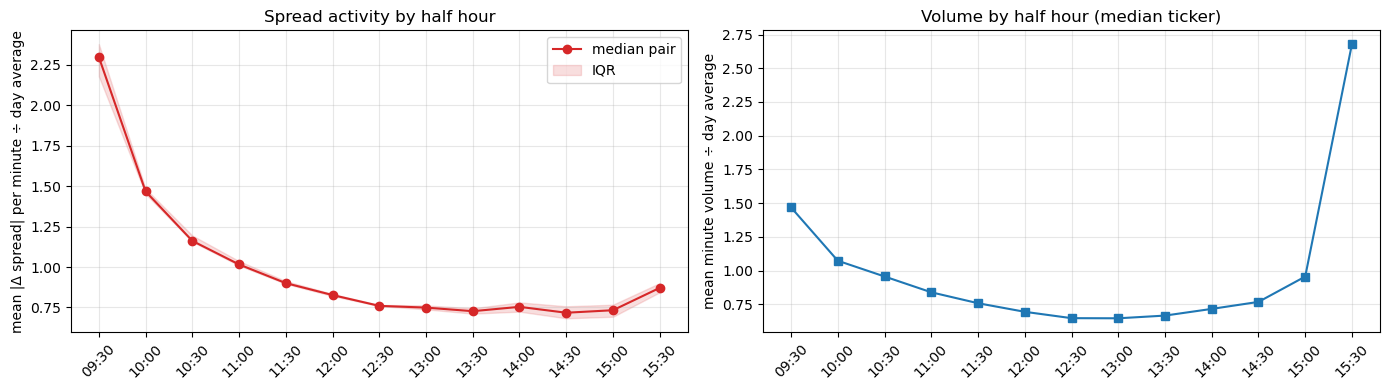

share of the spread's close-to-close variance that occurs OVERNIGHT (median pair): 39%  (IQR 33%–44%); the overnight gap is 15× a typical minute move


In [15]:
minute_of_day = (close_1m.index.hour * 60 + close_1m.index.minute).to_numpy()
bucket = np.clip((minute_of_day - 570) // 30, 0, 12)                          # 13 half-hour buckets 09:30 … 15:30
labels = [f"{(570 + 30 * b) // 60:02d}:{(570 + 30 * b) % 60:02d}" for b in range(13)]
d_spread = spreads_1m.diff()
new_session = session_of.to_series().ne(session_of.to_series().shift()).to_numpy()
d_spread[new_session] = np.nan                                                  # no overnight differences
abs_move = d_spread.abs().groupby(bucket).mean()
abs_move = abs_move.div(abs_move.mean())                                        # relative to the day's average minute
volume_shape = vol_1m.groupby(bucket).mean(); volume_shape = volume_shape.div(volume_shape.mean())
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(range(13), abs_move.median(axis=1), marker="o", color="tab:red", label="median pair"); ax[0].fill_between(range(13), abs_move.quantile(.25, axis=1), abs_move.quantile(.75, axis=1), color="tab:red", alpha=.15, label="IQR")
ax[0].set_xticks(range(13)); ax[0].set_xticklabels(labels, rotation=45); ax[0].set_ylabel("mean |Δ spread| per minute ÷ day average"); ax[0].set_title("Spread activity by half hour"); ax[0].legend()
ax[1].plot(range(13), volume_shape.median(axis=1), marker="s", color="tab:blue"); ax[1].set_xticks(range(13)); ax[1].set_xticklabels(labels, rotation=45); ax[1].set_ylabel("mean minute volume ÷ day average"); ax[1].set_title("Volume by half hour (median ticker)")
plt.tight_layout(); plt.show()

# overnight vs intraday variance of the spread
first = spreads_1m.groupby(session_of.to_numpy()).first(); last = spreads_1m.groupby(session_of.to_numpy()).last()
overnight = (first - last.shift(1)).dropna(); intraday = (last - first)
share = (overnight.var() / (overnight.var() + intraday.var()))
print("share of the spread's close-to-close variance that occurs OVERNIGHT (median pair): "
      f"{share.median():.0%}  (IQR {share.quantile(.25):.0%}–{share.quantile(.75):.0%}); "
      f"the overnight gap is {(overnight.std() / d_spread.std()).median():.0f}× a typical minute move")

### 6.4 What a trade is worth against what it costs

An entry at $|z| = 2$ that reverts to $|z| = 0.5$ earns about $1.5\,\sigma_z$ of spread, where $\sigma_z$
is the standard deviation of the spread over the z-score look-back. On a $10{,}000 dollar-neutral
position that is worth $1.5\,\sigma_z / \text{(price of one unit of spread)}$ in return terms. Against it:
two legs, each crossing the effective (Roll) spread twice per round trip, plus commission.

The table compares, per pair, the gross value of a 2 → 0.5 reversion when the look-back is one hour, one
session and five sessions of minute bars, with the round-trip cost from the Roll spreads of the two legs
plus 1 bp per leg per side of commission and slippage.

In [16]:
COMMISSION_BPS = 1.0
roll_bps = liquid["median_roll_bps"].reindex(cand_tickers)
rows = []
for (a, b), lbl in zip(candidates.index, pair_labels):
    s = spreads_1m[lbl]
    unit_notional = (close_1m[a] + abs(hedges[(a, b)][1]) * close_1m[b]).median()      # $ price of one unit of spread
    row = {"pair": lbl, "Roll a (bps)": roll_bps[a], "Roll b (bps)": roll_bps[b]}
    # round trip: each leg crosses its half-spread twice (in and out) -> Roll spread once per leg, + commission per side
    row["round-trip cost (bps of notional)"] = 0.5 * (roll_bps[a] + roll_bps[b]) + 4 * COMMISSION_BPS
    for name, win in (("1 hour", 60), ("1 session", 390), ("5 sessions", 5 * 390)):
        sigma = s.rolling(win, min_periods=win).std().median()
        row[f"1.5σ reversion, {name} look-back (bps)"] = 1.5 * sigma / unit_notional * 1e4
    rows.append(row)
econ = pd.DataFrame(rows).set_index("pair")
display(econ.round(1))
print("median across pairs:"); print(econ.median().round(1).to_string())

,Roll a (bps),Roll b (bps),round-trip cost (bps of notional),"1.5σ reversion, 1 hour look-back (bps)","1.5σ reversion, 1 session look-back (bps)","1.5σ reversion, 5 sessions look-back (bps)"
pair,,,,,,
PYPL/TSN,4.1,3.0,7.5,17.0,54.0,134.2
GM/WFC,4.0,3.5,7.8,15.6,49.1,125.6
PYPL/TFC,4.1,3.5,7.8,15.5,48.2,119.7
APTV/WM,5.1,2.9,8.0,18.2,55.4,139.8
TROW/USB,4.1,3.3,7.7,14.0,41.7,101.4
TROW/VZ,4.1,2.6,7.4,15.7,50.0,128.2
TROW/WFC,4.1,3.5,7.8,18.5,57.1,141.7
JPM/NFLX,2.6,4.4,7.5,15.7,50.2,121.7
TROW/VTR,4.1,3.6,7.8,18.6,58.4,151.7


median across pairs:
Roll a (bps)                                    4.1
Roll b (bps)                                    3.4
round-trip cost (bps of notional)               7.8
1.5σ reversion, 1 hour look-back (bps)         15.7
1.5σ reversion, 1 session look-back (bps)      50.1
1.5σ reversion, 5 sessions look-back (bps)    126.9


## 7. What this means for the backtest

* **Microstructure noise is mild in these names.** At one-minute sampling the spread's realized variance
  is only ~9% above its 30-minute level (legs: ~2%), the Epps correlation of the legs' returns rises from
  0.30 to 0.34 between one and thirty minutes, and the first-order autocorrelation of minute spread
  changes is about −0.05. Nothing here forces coarse sampling — but nothing rewards fine sampling either.
* **The spread reverts over weeks, not minutes.** The half-life of the static spread is ≈ 8,000 minutes
  (≈ 20 sessions) whichever interval it is sampled at, matching ≈ 17 days on session closes. Minute bars
  do not reveal a faster mean reversion; they only resolve *where within the day* one enters and exits.
* **A short look-back trades noise at a loss.** With a one-hour look-back a 2 → 0.5 reversion is worth
  ≈ 16 bps against a round-trip cost of ≈ 8 bps (Roll spreads of 3–4 bps per leg plus commission); with a
  five-session look-back it is worth ≈ 130 bps. Look-backs must be counted in sessions.
* **Overnight matters.** About 40% of the spread's close-to-close variance occurs overnight, and the gap is
  ≈ 15 times a typical minute move. A strategy that flattens at the close forfeits much of the reversion and
  re-enters after the gap.
* **Fast hedges are dangerous.** A Kalman filter re-estimating the hedge every minute will absorb the
  slow reversion into its state and leave a residual that is white at the bar scale (notebook 16 shows this
  directly). The hedge should move at most daily.

Notebook 16 turns these into a walk-forward comparison: hedge cadence, sampling frequency, session rule,
look-back and threshold — chosen on pooled out-of-fold Sharpe over 2022–2024 with 2025 untouched.